In [1]:
##### Plots feature importance for final RF models

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

In [2]:
##### SET-UP

# Get the current working directory
cd = Path.cwd().parent.parent 

# import models
capital = pd.read_csv(f'{cd}/Results/RF_models_final/capital_rf_spatial_CV/feature_importance.csv')
labor = pd.read_csv(f'{cd}/Results/RF_models_final/labor_rf_spatial_CV/feature_importance.csv')

# final var names 
names = pd.read_csv(f"{cd}/Data/Correspondence_tables/final_RF_var_names.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/feature_importance"

In [3]:
### Prep data

capital = capital.merge(names, on='feature', how='left')
labor = labor.merge(names, on='feature', how='left')


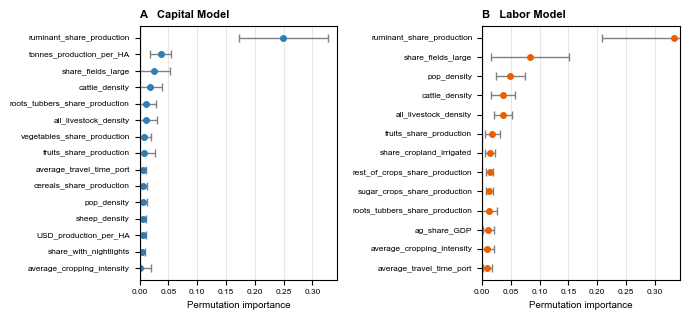

In [6]:
#### Feature importance: capital vs labor (permutation importance)

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

# Cell Press double-column width is ~7 in; scale height to content
fig, axes = plt.subplots(1, 2, figsize=(7, max(len(capital), len(labor)) * 0.18 + 0.6), sharex=True)

panel_colors = ["#2c7fb8", "#e66101"]
panel_labels = ["A", "B"]

def plot_feature_importance(ax, df, panel_label, panel_title, color):
    df_sorted = df.sort_values("permutation_mean", ascending=True)

    ax.errorbar(
        df_sorted["permutation_mean"], df_sorted["name"],
        xerr=df_sorted["permutation_std"],
        fmt="o", color=color, ecolor="grey", elinewidth=1, capsize=3,
        markersize=4, zorder=2
    )

    ax.axvline(0, color="black", linewidth=0.8, zorder=1)
    ax.set_title(f"{panel_label}   {panel_title}", loc="left", fontsize=8, weight="bold")
    ax.set_xlabel("Permutation importance", fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(left=0)

plot_feature_importance(axes[0], capital, panel_labels[0], "Capital Model", panel_colors[0])
plot_feature_importance(axes[1], labor, panel_labels[1], "Labor Model", panel_colors[1])

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/feature_importance_permutation_side_by_side.tiff", dpi=300, bbox_inches="tight")